In [1]:
import agama
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from kinematic_decompose.mixture import *
from kinematic_decompose.PyTNG.snapshot_loader import Snapshot
from kinematic_decompose.visualize import visualize_decomposition
from kinematic_decompose.gravity.kinematic_solver import calculate_kinematic_param, construct_galaxy_potential_model
from kinematic_decompose.config import BASEPATH

加载粒子

In [2]:
run = 'TNG50-1'
snapNum = 99
subID   = 307486
basePath = f"{BASEPATH}/{run}/output"
snapshot = Snapshot(basePath, snapNum)
load_particle_fields = {"star": ['Coordinates', 'Velocities', 'Masses', 'GFM_StellarFormationTime'],
                        "dm": ['Coordinates', 'Velocities', 'Masses'],
                        "gas": ['Coordinates', 'Velocities', 'Masses']}
snapshot.load_particle(ID = subID, load_particle_fields=load_particle_fields)
snapshot.physical_units()
snapshot.load_group_catalog(ID=subID)
snapshot.GC_physical_units()
snapshot.center(cen=snapshot.group_catalog['SubhaloPos'])
snapshot.faceon(align_with='star', range=[3*snapshot.properties['eps'], 5*snapshot.s.r50], as_context=False)
galaxy = snapshot.container

计算势场和运动学参数

In [3]:
pot = construct_galaxy_potential_model(galaxy)
galaxy = calculate_kinematic_param(galaxy, potential=pot)

不太重要的东西

In [4]:
X = np.column_stack([galaxy.s['eoemin'], galaxy.s['jzojc'], galaxy.s['jpojc']])
keep_particle = (galaxy.s['eoemin']<0)&(np.abs(galaxy.s['jzojc'])<1.5)&(galaxy.s['jpojc']<1.5)
"""
Determine the Ecut
"""
RCUT_RANGE = (1, 10)
sph, _ = util.JEHistogram(galaxy.s['eoemin'][keep_particle], galaxy.s['jzojc'][keep_particle], n_E=25, n_eps=50)
sph = (sph) & (np.abs(galaxy.s['jzojc'][keep_particle])<=0.5)
eoemin_cut= util.get_Ecut(galaxy.s['eoemin'][keep_particle][sph], galaxy.s['mass'][keep_particle][sph], M_bin=100, m_bin=25, Mmin=0.1)
r = np.logspace(-1, 1, 100)
points = np.column_stack((r*0, r*0, r))
potential = pot.potential(points)
max_eoemin_cut = (potential/np.abs(galaxy.s['e'].min()))[np.searchsorted(r, RCUT_RANGE[1])]
min_eoemin_cut = (potential/np.abs(galaxy.s['e'].min()))[np.searchsorted(r, RCUT_RANGE[0])]
if eoemin_cut == 0 or max_eoemin_cut < eoemin_cut or eoemin_cut < min_eoemin_cut:
    eoemin_cut = (potential/np.abs(galaxy.s['e'].min()))[np.searchsorted(r, 3.5)]

jzojc_cut = 0.5

eoemin_index = 0
jzojc_index = 1
jpojc_index = 2

数据预处理

In [5]:
scaler = preprocessing.RobustScaler()
X_train= scaler.fit_transform(X[keep_particle])
eoemin_cut_train = scaler.transform(eoemin_cut, columns=eoemin_index)
jzojc_cut_train = scaler.transform(jzojc_cut, columns=jzojc_index)
r_jzojc_cut_train = scaler.transform(-jzojc_cut, columns=jzojc_index)

训练模型

In [6]:
auto_gmm = AutoGaussianMixtureModel()
auto_gmm = auto_gmm.fit(X_train, 
                        eoemin_cut=eoemin_cut_train, 
                        jzojc_cut=jzojc_cut_train,
                        r_jzojc_cut = r_jzojc_cut_train, 
                        sample_weight=galaxy.s['mass'][keep_particle],
                        max_iter=100, 
                        min_iter=10,
                        scaler=scaler,
                        use_float32=True)
best_model = scaler.inverse_transform_GMM(auto_gmm.best_model)

分解模型

In [7]:
galaxy = util.decompose(X, galaxy, best_model, eoemin_cut, jzojc_cut, predict_method='hard')

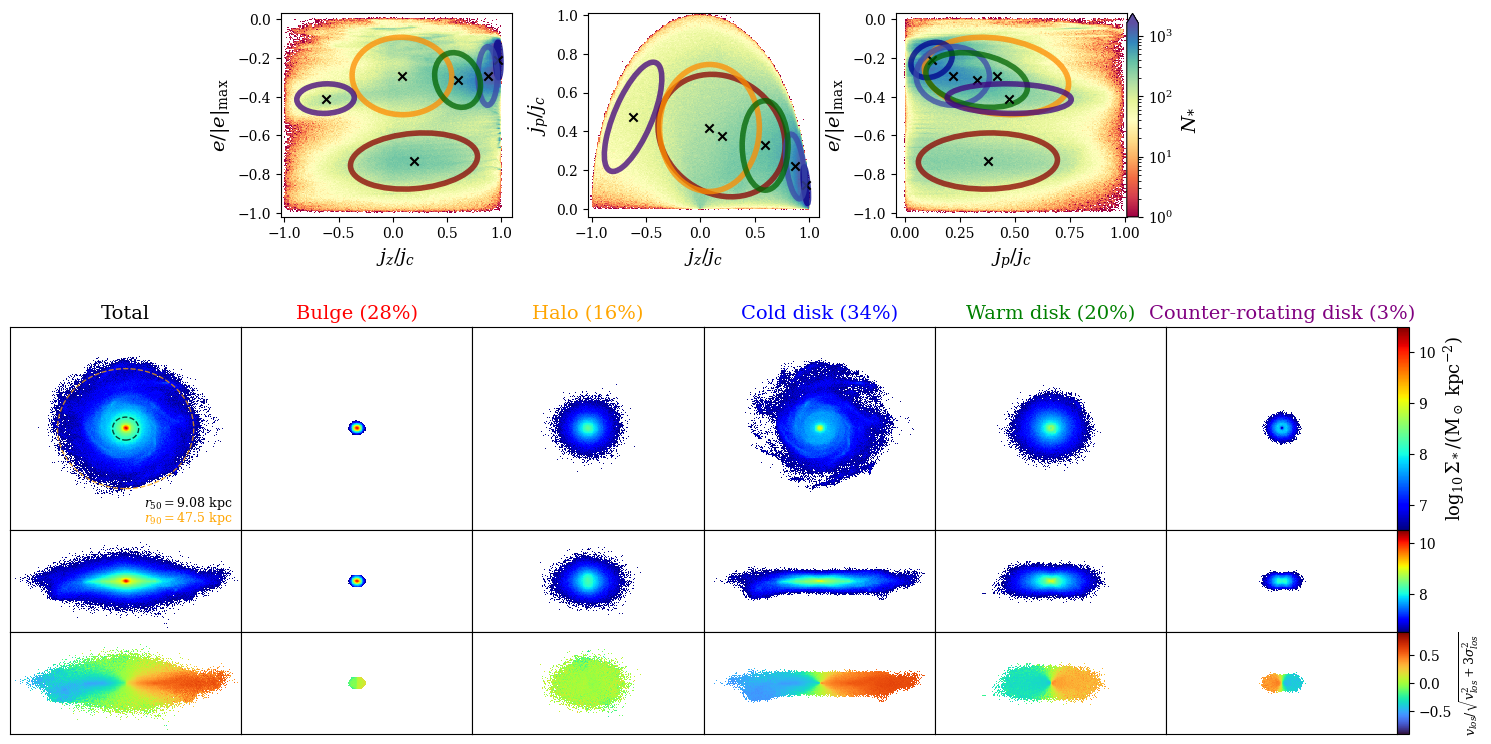

In [8]:
fig = visualize_decomposition(X, best_model, galaxy, eoemin_cut, jzojc_cut)
plt.show()

In [16]:
galaxy.colddisk['age']

SimArray([ 9.22687818,  9.13414086,  9.75801102, ..., 11.98722024,
           8.51681547,  8.48183066], shape=(1669543,), 'Gyr')